In [1]:
# ============================================================================
# CTAB-GAN with Differential Privacy, KL/JS Divergence, and Bug Fixes
# ============================================================================

import os, math, numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.nn.utils import spectral_norm, clip_grad_norm_
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from dataclasses import dataclass
from typing import Optional, Callable
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, chi2_contingency, entropy
from scipy.spatial.distance import jensenshannon
import warnings
warnings.filterwarnings('ignore')

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [2]:
# ============================================================================
# 1. DATA LOADING AND PREPROCESSING
# ============================================================================

# Load your data
data_path = "/kaggle/input/taiwan-credit-card-dataset/data.csv"  # Update path
df = pd.read_csv(data_path)

# Remove ID column if present
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])

print(f"Loaded data: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Loaded data: (30000, 24)
Columns: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default']


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
# ============================================================================
# 2. TYPE INFERENCE AND PREPROCESSING
# ============================================================================

def infer_types(df, max_cat_unique=50, cat_frac_threshold=0.1):
    """Infer which columns are numeric vs categorical"""
    n = len(df)
    num_cols, cat_cols = [], []
    for c in df.columns:
        s = df[c]
        if pd.api.types.is_numeric_dtype(s):
            nunique = s.nunique(dropna=True)
            # Treat as categorical if low cardinality integers
            if (nunique <= max(max_cat_unique, int(cat_frac_threshold*n))) and \
               (pd.api.types.is_integer_dtype(s)):
                cat_cols.append(c)
            else:
                num_cols.append(c)
        else:
            cat_cols.append(c)
    return num_cols, cat_cols

num_cols, cat_cols = infer_types(df)
print(f"Numeric columns ({len(num_cols)}): {num_cols}")
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")

Numeric columns (12): ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Categorical columns (12): ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'default']


In [4]:
# ============================================================================
# 3. CONDITIONAL VECTOR CREATION
# ============================================================================

# Select a subset of categorical columns for conditioning
# You can also use numeric columns or all columns
cond_cols = cat_cols[:min(3, len(cat_cols))]  # Use first 3 categorical columns
print(f"Conditioning on: {cond_cols}")

# Create one-hot encoded conditional vectors
if cond_cols:
    cond_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    cond_full = cond_encoder.fit_transform(df[cond_cols])
    cond_dim = cond_full.shape[1]
else:
    cond_full = np.zeros((len(df), 1))
    cond_dim = 1

print(f"Conditional dimension: {cond_dim}")

Conditioning on: ['LIMIT_BAL', 'SEX', 'EDUCATION']
Conditional dimension: 90


In [5]:
# ============================================================================
# 4. DATA TRANSFORMATION PIPELINE
# ============================================================================

class ToRangeMinus1To1(BaseEstimator, TransformerMixin):
    """Transform from [0,1] to [-1,1] range"""
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return 2.0 * X - 1.0
    def inverse_transform(self, X):
        return (X + 1.0) / 2.0

# Numeric pipeline: QuantileTransform -> [-1, 1]
num_pipe = Pipeline([
    ("qt", QuantileTransformer(output_distribution="uniform", random_state=0)),
    ("rng", ToRangeMinus1To1())
])

# Categorical pipeline: OneHotEncoder
cat_pipe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# Combined preprocessor
pre = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ],
    remainder="drop"
)

# Fit and transform
X_proc = pre.fit_transform(df)
print(f"Processed shape: {X_proc.shape}")
print(f"Processed range: [{X_proc.min():.3f}, {X_proc.max():.3f}]")

Processed shape: (30000, 228)
Processed range: [-1.000, 1.000]


In [6]:
# ============================================================================
# 5. CONDITIONAL SAMPLER
# ============================================================================

def cond_sampler(batch_size: int) -> torch.Tensor:
    """Sample random conditional vectors"""
    idx = np.random.randint(0, X_proc.shape[0], size=batch_size)
    return torch.tensor(cond_full[idx], dtype=torch.float32)

# Convert to torch tensor
real_tensor = torch.tensor(X_proc, dtype=torch.float32)
input_dim = real_tensor.shape[1]
print(f"Input dimension: {input_dim}")

Input dimension: 228


In [7]:
# ============================================================================
# 6. GAN ARCHITECTURE WITH SPECTRAL NORMALIZATION
# ============================================================================

def orthogonal_init(m: nn.Module):
    """Initialize weights with orthogonal initialization"""
    if isinstance(m, nn.Linear):
        nn.init.orthogonal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

class SpectralLinear(nn.Module):
    """Linear layer with spectral normalization"""
    def __init__(self, in_features, out_features, bias=True):
        super().__init__()
        self.lin = spectral_norm(nn.Linear(in_features, out_features, bias=bias))
    
    def forward(self, x):
        return self.lin(x)

class LayerBlock(nn.Module):
    """Basic building block with optional spectral normalization"""
    def __init__(self, in_f, out_f, use_sn: bool = False, dropout: float = 0.0):
        super().__init__()
        self.fc = SpectralLinear(in_f, out_f) if use_sn else nn.Linear(in_f, out_f)
        self.ln = nn.LayerNorm(out_f)
        self.act = nn.LeakyReLU(0.2, inplace=True)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
    
    def forward(self, x):
        x = self.fc(x)
        x = self.ln(x)
        x = self.act(x)
        x = self.dropout(x)
        return x

class Generator(nn.Module):
    """Generator network"""
    def __init__(self, noise_dim: int, cond_dim: int, out_dim: int, 
                 hidden: int = 128, num_layers: int = 3, dropout: float = 0.0):
        super().__init__()
        in_dim = noise_dim + cond_dim
        layers = [LayerBlock(in_dim, hidden, use_sn=False, dropout=dropout)]
        for _ in range(num_layers - 1):
            layers.append(LayerBlock(hidden, hidden, use_sn=False, dropout=dropout))
        self.mlp = nn.Sequential(*layers)
        self.out = nn.Linear(hidden, out_dim)
        self.final_act = nn.Tanh()  # Tanh to constrain output to [-1, 1]
        self.apply(orthogonal_init)
    
    def forward(self, z, cond):
        x = torch.cat([z, cond], dim=1)
        x = self.mlp(x)
        x = self.out(x)
        return self.final_act(x)

class Critic(nn.Module):
    """Critic (Discriminator) network with spectral normalization"""
    def __init__(self, in_dim: int, hidden: int = 128, num_layers: int = 3, dropout: float = 0.0):
        super().__init__()
        layers = [LayerBlock(in_dim, hidden, use_sn=True, dropout=dropout)]
        for _ in range(num_layers - 1):
            layers.append(LayerBlock(hidden, hidden, use_sn=True, dropout=dropout))
        self.mlp = nn.Sequential(*layers)
        self.out = SpectralLinear(hidden, 1)
        self.apply(orthogonal_init)
    
    def forward(self, x):
        x = self.mlp(x)
        return self.out(x)

In [8]:
# ============================================================================
# 7. DIFFERENTIAL PRIVACY IMPLEMENTATION
# ============================================================================

class DifferentialPrivacyEngine:
    """
    Implements Differential Privacy using DP-SGD
    References:
    - Abadi et al. (2016): Deep Learning with Differential Privacy
    - https://arxiv.org/abs/1607.00133
    """
    def __init__(self, noise_multiplier: float = 1.0, max_grad_norm: float = 1.0):
        self.noise_multiplier = noise_multiplier
        self.max_grad_norm = max_grad_norm
        self.steps = 0
    
    def clip_and_accumulate_gradients(self, model: nn.Module, per_sample_grads):
        """
        Clip per-sample gradients and accumulate
        """
        # Clip each sample's gradient
        clipped_grads = []
        for grad in per_sample_grads:
            grad_norm = grad.norm(2)
            clip_coef = min(1.0, self.max_grad_norm / (grad_norm + 1e-6))
            clipped_grads.append(grad * clip_coef)
        
        # Average the clipped gradients
        return torch.stack(clipped_grads).mean(dim=0)
    
    def add_noise_to_gradients(self, model: nn.Module, batch_size: int):
        """
        Add Gaussian noise to gradients for differential privacy
        """
        for param in model.parameters():
            if param.grad is not None:
                noise = torch.randn_like(param.grad) * self.noise_multiplier * self.max_grad_norm / batch_size
                param.grad += noise
        self.steps += 1
    
    def compute_epsilon(self, dataset_size: int, batch_size: int, epochs: int, delta: float = 1e-5):
        """
        Compute privacy budget (epsilon) using the moments accountant method
        This is a simplified approximation
        """
        q = batch_size / dataset_size  # Sampling ratio
        steps = (dataset_size / batch_size) * epochs
        
        # Simplified epsilon calculation (approximate)
        # For more accurate calculation, use the opacus library
        sigma = self.noise_multiplier
        epsilon = q * steps / (sigma ** 2) * np.sqrt(2 * np.log(1.25 / delta))
        
        return epsilon

In [9]:
# ============================================================================
# 8. TRAINING CONFIGURATION
# ============================================================================

@dataclass
class TrainConfig:
    input_dim: int
    cond_dim: int
    noise_dim: int = 64
    g_hidden: int = 128
    d_hidden: int = 128
    g_layers: int = 3
    d_layers: int = 3
    batch_size: int = 64
    n_epochs: int = 100
    n_critic: int = 5
    lr_g: float = 1e-4
    lr_d: float = 1e-4
    beta1: float = 0.0
    beta2: float = 0.9
    lambda_gp: float = 10.0
    grad_clip_g: float = 1.0
    grad_clip_d: float = 1.0
    inst_noise_sigma0: float = 0.1
    inst_noise_min: float = 0.0
    inst_noise_anneal: str = "exp"
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    clamp_min: Optional[float] = None  # No clamping for Tanh output
    clamp_max: Optional[float] = None
    use_amp: bool = True
    seed: Optional[int] = 42
    dropout: float = 0.1
    # Differential Privacy parameters
    use_dp: bool = True
    dp_noise_multiplier: float = 0.5
    dp_max_grad_norm: float = 1.0
    dp_delta: float = 1e-5

In [10]:
# ============================================================================
# 9. HELPER FUNCTIONS
# ============================================================================

def _annealed_sigma(cfg: TrainConfig, epoch: int) -> float:
    """Anneal instance noise over training"""
    if cfg.inst_noise_sigma0 <= 0:
        return 0.0
    T = max(cfg.n_epochs - 1, 1)
    if cfg.inst_noise_anneal == "linear":
        frac = 1.0 - (epoch / T)
        return cfg.inst_noise_min + (cfg.inst_noise_sigma0 - cfg.inst_noise_min) * frac
    else:
        k = 5.0
        frac = math.exp(-k * (epoch / T))
        return cfg.inst_noise_min + (cfg.inst_noise_sigma0 - cfg.inst_noise_min) * frac

def _add_instance_noise(x: torch.Tensor, sigma: float) -> torch.Tensor:
    """Add instance noise for stability"""
    if sigma <= 0:
        return x
    return x + sigma * torch.randn_like(x)

def gradient_penalty(critic: nn.Module, real: torch.Tensor, fake: torch.Tensor, device: str) -> torch.Tensor:
    """Compute gradient penalty for WGAN-GP"""
    bsz = real.size(0)
    eps = torch.rand(bsz, 1, device=device).expand(-1, real.size(1))
    inter = eps * real + (1 - eps) * fake
    inter.requires_grad_(True)
    score = critic(inter)
    grad = torch.autograd.grad(outputs=score, inputs=inter,
                               grad_outputs=torch.ones_like(score),
                               create_graph=True, retain_graph=True, only_inputs=True)[0]
    grad = grad.view(bsz, -1)
    gp = ((grad.norm(2, dim=1) - 1.0) ** 2).mean()
    return gp

@torch.no_grad()
def clamp_range(x, lo, hi):
    """Clamp values to range (if specified)"""
    if lo is None or hi is None:
        return x
    return x.clamp(lo, hi)

In [11]:
# ============================================================================
# 10. TRAINING FUNCTION WITH DIFFERENTIAL PRIVACY
# ============================================================================

def train_ctabgan_stable(real_data: torch.Tensor, cond_sampler: Callable, cfg: TrainConfig):
    """
    Train CTAB-GAN with Wasserstein loss, gradient penalty, spectral normalization,
    and optional differential privacy
    """
    if cfg.seed is not None:
        torch.manual_seed(cfg.seed)
        torch.cuda.manual_seed_all(cfg.seed)
        np.random.seed(cfg.seed)

    device = cfg.device
    N, D = real_data.shape
    assert D == cfg.input_dim, f"input_dim mismatch: data {D} vs cfg {cfg.input_dim}"
    real_data = real_data.to(device)

    # Initialize networks
    G = Generator(cfg.noise_dim, cfg.cond_dim, cfg.input_dim, 
                  hidden=cfg.g_hidden, num_layers=cfg.g_layers, dropout=cfg.dropout).to(device)
    Dnet = Critic(cfg.input_dim, hidden=cfg.d_hidden, num_layers=cfg.d_layers, dropout=cfg.dropout).to(device)

    # Optimizers
    optG = torch.optim.Adam(G.parameters(), lr=cfg.lr_g, betas=(cfg.beta1, cfg.beta2))
    optD = torch.optim.Adam(Dnet.parameters(), lr=cfg.lr_d, betas=(cfg.beta1, cfg.beta2))

    # Mixed precision scalers
    scalerG = torch.cuda.amp.GradScaler(enabled=cfg.use_amp and device.startswith("cuda"))
    scalerD = torch.cuda.amp.GradScaler(enabled=cfg.use_amp and device.startswith("cuda"))

    # Differential Privacy Engine
    dp_engine = None
    if cfg.use_dp:
        dp_engine = DifferentialPrivacyEngine(
            noise_multiplier=cfg.dp_noise_multiplier,
            max_grad_norm=cfg.dp_max_grad_norm
        )
        print(f"Training with Differential Privacy (σ={cfg.dp_noise_multiplier}, C={cfg.dp_max_grad_norm})")

    # Training history
    hist = {
        "g_loss": [],
        "d_loss": [],
        "gp": [],
        "w_dist": []  # Wasserstein distance estimate
    }

    def sample_real(b):
        idx = torch.randint(0, N, (b,), device=device)
        return real_data[idx]

    print(f"Starting training for {cfg.n_epochs} epochs...")
    
    for epoch in range(cfg.n_epochs):
        sigma = _annealed_sigma(cfg, epoch)
        n_steps = max(1, N // cfg.batch_size)
        g_epoch = 0.0
        d_epoch = 0.0
        gp_epoch = 0.0
        wd_epoch = 0.0

        for step in range(n_steps):
            # =================================================================
            # Train Critic (Discriminator)
            # =================================================================
            for _ in range(cfg.n_critic):
                x_real = sample_real(cfg.batch_size)
                if sigma > 0:
                    x_real = _add_instance_noise(x_real, sigma)

                z = torch.randn(cfg.batch_size, cfg.noise_dim, device=device)
                cond = cond_sampler(cfg.batch_size).to(device)
                
                with torch.cuda.amp.autocast(enabled=scalerD.is_enabled()):
                    x_fake = G(z, cond).detach()
                    x_fake = clamp_range(x_fake, cfg.clamp_min, cfg.clamp_max)
                    if sigma > 0:
                        x_fake = _add_instance_noise(x_fake, sigma)
                    
                    d_real = Dnet(x_real)
                    d_fake = Dnet(x_fake)
                    gp = gradient_penalty(Dnet, x_real, x_fake, device) * cfg.lambda_gp
                    d_loss = (d_fake.mean() - d_real.mean()) + gp
                    
                    # Track Wasserstein distance estimate
                    w_dist = d_real.mean() - d_fake.mean()

                optD.zero_grad(set_to_none=True)
                scalerD.scale(d_loss).backward()
                scalerD.unscale_(optD)
                
                # Gradient clipping
                if cfg.grad_clip_d and cfg.grad_clip_d > 0:
                    clip_grad_norm_(Dnet.parameters(), cfg.grad_clip_d)
                
                # Add DP noise to discriminator gradients
                if dp_engine:
                    dp_engine.add_noise_to_gradients(Dnet, cfg.batch_size)
                
                scalerD.step(optD)
                scalerD.update()
                
                d_epoch += d_loss.item()
                gp_epoch += gp.item()
                wd_epoch += w_dist.item()

            # =================================================================
            # Train Generator
            # =================================================================
            z = torch.randn(cfg.batch_size, cfg.noise_dim, device=device)
            cond = cond_sampler(cfg.batch_size).to(device)
            
            with torch.cuda.amp.autocast(enabled=scalerG.is_enabled()):
                x_fake = G(z, cond)
                x_fake = clamp_range(x_fake, cfg.clamp_min, cfg.clamp_max)
                g_loss = -Dnet(x_fake).mean()

            optG.zero_grad(set_to_none=True)
            scalerG.scale(g_loss).backward()
            scalerG.unscale_(optG)
            
            # Gradient clipping
            if cfg.grad_clip_g and cfg.grad_clip_g > 0:
                clip_grad_norm_(G.parameters(), cfg.grad_clip_g)
            
            scalerG.step(optG)
            scalerG.update()
            
            g_epoch += g_loss.item()

        # Store epoch statistics
        hist["g_loss"].append(g_epoch / n_steps)
        hist["d_loss"].append(d_epoch / (n_steps * cfg.n_critic))
        hist["gp"].append(gp_epoch / (n_steps * cfg.n_critic))
        hist["w_dist"].append(wd_epoch / (n_steps * cfg.n_critic))

        # Print progress
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{cfg.n_epochs}] | "
                  f"G Loss: {hist['g_loss'][-1]:.4f} | "
                  f"D Loss: {hist['d_loss'][-1]:.4f} | "
                  f"GP: {hist['gp'][-1]:.4f} | "
                  f"W-Dist: {hist['w_dist'][-1]:.4f} | "
                  f"σ_inst: {sigma:.4f}")

    # Compute privacy budget if using DP
    if dp_engine:
        epsilon = dp_engine.compute_epsilon(N, cfg.batch_size, cfg.n_epochs, cfg.dp_delta)
        print(f"\nPrivacy Budget: ε = {epsilon:.2f} (δ = {cfg.dp_delta})")
        hist["epsilon"] = epsilon
        hist["delta"] = cfg.dp_delta

    G.eval()
    Dnet.eval()
    
    return {
        "G": G,
        "D": Dnet,
        "history": hist,
        "config": cfg,
        "dp_engine": dp_engine
    }

In [12]:
# ============================================================================
# 11. SYNTHETIC DATA GENERATION AND INVERSE TRANSFORM
# ============================================================================

@torch.no_grad()
def sample_synth(G, cond_sampler, cfg, n=1000):
    """Generate synthetic samples"""
    G.eval()
    z = torch.randn(n, cfg.noise_dim, device=cfg.device)
    cond = cond_sampler(n).to(cfg.device)
    x = G(z, cond).cpu().numpy()
    return x

def inverse_transform_fixed(pre, X_proc, df_template):
    """
    Fixed inverse transform that properly handles the data
    
    FIXES THE ZERO VALUES BUG:
    1. Properly clips values before inverse transform
    2. Handles edge cases in quantile transform
    3. Correctly reconstructs categorical variables
    """
    # Get column information
    num_cols = pre.transformers_[0][2] if len(pre.transformers_) > 0 else []
    cat_cols = pre.transformers_[1][2] if len(pre.transformers_) > 1 else []
    
    # Get fitted transformers
    num_transformer = pre.named_transformers_.get("num") if len(num_cols) > 0 else None
    cat_transformer = pre.named_transformers_.get("cat") if len(cat_cols) > 0 else None
    
    out = pd.DataFrame(index=range(X_proc.shape[0]))
    start = 0
    
    # =========================================================================
    # Inverse transform NUMERIC columns
    # =========================================================================
    if len(num_cols) > 0 and num_transformer is not None:
        num_dim = len(num_cols)
        Xn = X_proc[:, start:start+num_dim]
        start += num_dim
        
        # Get the QuantileTransformer
        qt = num_transformer.named_steps["qt"]
        to_range = num_transformer.named_steps["rng"]
        
        # Inverse transform: [-1,1] -> [0,1]
        Xn_uniform = to_range.inverse_transform(Xn)
        
        # Clip to valid range to avoid numerical issues
        Xn_uniform = np.clip(Xn_uniform, 1e-7, 1 - 1e-7)
        
        # Inverse quantile transform
        Xn_inv = qt.inverse_transform(Xn_uniform)
        
        # Assign to dataframe
        out[num_cols] = Xn_inv
    
    # =========================================================================
    # Inverse transform CATEGORICAL columns
    # =========================================================================
    if len(cat_cols) > 0 and cat_transformer is not None:
        # Get one-hot dimension
        oh_dim = cat_transformer.transform(df_template[cat_cols].iloc[:1]).shape[1]
        Xc = X_proc[:, start:start+oh_dim]
        start += oh_dim
        
        # Get categories for each column
        cats = cat_transformer.categories_
        col_ptr = 0
        
        for col, cats_list in zip(cat_cols, cats):
            k = len(cats_list)
            block = Xc[:, col_ptr:col_ptr+k]
            
            # Apply softmax to convert to probabilities, then argmax
            # This handles cases where the network outputs aren't properly normalized
            block_softmax = np.exp(block) / np.exp(block).sum(axis=1, keepdims=True)
            idx = block_softmax.argmax(axis=1)
            
            out[col] = np.array(cats_list)[idx]
            col_ptr += k
    
    # Reorder columns to match original
    out = out[df_template.columns]
    
    return out


In [13]:
# ============================================================================
# 12. EVALUATION METRICS: KL and JS Divergence
# ============================================================================

def compute_histogram_probs(data, bins=50, range_vals=None):
    """Compute histogram probabilities for divergence calculation"""
    if range_vals is None:
        range_vals = (data.min(), data.max())
    
    hist, _ = np.histogram(data, bins=bins, range=range_vals, density=True)
    # Normalize to get probabilities
    hist = hist + 1e-10  # Add small constant to avoid log(0)
    hist = hist / hist.sum()
    return hist

def kl_divergence(real_data, syn_data, bins=50):
    """
    Compute KL Divergence: KL(P || Q) where P is real, Q is synthetic
    KL(P || Q) = sum(P(i) * log(P(i) / Q(i)))
    """
    # Get common range
    min_val = min(real_data.min(), syn_data.min())
    max_val = max(real_data.max(), syn_data.max())
    range_vals = (min_val, max_val)
    
    # Compute histograms
    p = compute_histogram_probs(real_data, bins=bins, range_vals=range_vals)
    q = compute_histogram_probs(syn_data, bins=bins, range_vals=range_vals)
    
    # Compute KL divergence
    kl = entropy(p, q)
    return kl

def js_divergence(real_data, syn_data, bins=50):
    """
    Compute JS Divergence: JS(P || Q)
    JS is symmetric and bounded [0, 1] (in bits) or [0, ln(2)] (in nats)
    """
    # Get common range
    min_val = min(real_data.min(), syn_data.min())
    max_val = max(real_data.max(), syn_data.max())
    range_vals = (min_val, max_val)
    
    # Compute histograms
    p = compute_histogram_probs(real_data, bins=bins, range_vals=range_vals)
    q = compute_histogram_probs(syn_data, bins=bins, range_vals=range_vals)
    
    # Compute JS divergence
    js = jensenshannon(p, q, base=2)  # base=2 for bits
    return js

def compute_divergences_for_dataframes(df_real, df_syn, num_cols, cat_cols, bins=50):
    """
    Compute KL and JS divergences for all columns
    """
    results = {
        'column': [],
        'type': [],
        'kl_divergence': [],
        'js_divergence': []
    }
    
    # Numeric columns
    for col in num_cols:
        real_vals = df_real[col].values
        syn_vals = df_syn[col].values
        
        kl = kl_divergence(real_vals, syn_vals, bins=bins)
        js = js_divergence(real_vals, syn_vals, bins=bins)
        
        results['column'].append(col)
        results['type'].append('numeric')
        results['kl_divergence'].append(kl)
        results['js_divergence'].append(js)
    
    # Categorical columns
    for col in cat_cols:
        # Get value counts
        real_counts = df_real[col].value_counts(sort=False)
        syn_counts = df_syn[col].value_counts(sort=False)
        
        # Align categories
        all_cats = sorted(set(real_counts.index) | set(syn_counts.index))
        p = np.array([real_counts.get(c, 0) for c in all_cats]) + 1e-10
        q = np.array([syn_counts.get(c, 0) for c in all_cats]) + 1e-10
        
        # Normalize
        p = p / p.sum()
        q = q / q.sum()
        
        # Compute divergences
        kl = entropy(p, q)
        js = jensenshannon(p, q, base=2)
        
        results['column'].append(col)
        results['type'].append('categorical')
        results['kl_divergence'].append(kl)
        results['js_divergence'].append(js)
    
    return pd.DataFrame(results)

In [14]:
# ============================================================================
# 13. MAIN TRAINING EXECUTION
# ============================================================================

print("\n" + "="*80)
print("TRAINING CTAB-GAN WITH DIFFERENTIAL PRIVACY")
print("="*80 + "\n")

cfg = TrainConfig(
    input_dim=input_dim,
    cond_dim=cond_dim,
    noise_dim=64,
    g_hidden=128,
    d_hidden=128,
    g_layers=3,
    d_layers=3,
    batch_size=64,
    n_epochs=100,  # Increase for better results
    n_critic=5,
    lr_g=1e-4,
    lr_d=1e-4,
    beta1=0.0,
    beta2=0.9,
    lambda_gp=10.0,
    grad_clip_g=1.0,
    grad_clip_d=1.0,
    inst_noise_sigma0=0.1,
    inst_noise_min=0.0,
    inst_noise_anneal="exp",
    clamp_min=None,  # No clamping with Tanh
    clamp_max=None,
    use_amp=True,
    seed=42,
    dropout=0.1,
    # Differential Privacy settings
    use_dp=True,  # Set to False to disable DP
    dp_noise_multiplier=0.5,  # Lower = less privacy, better utility
    dp_max_grad_norm=1.0,
    dp_delta=1e-5
)

# Train the model
result = train_ctabgan_stable(real_tensor, cond_sampler, cfg)
G, D = result["G"], result["D"]

print(f"\nTraining complete!")
print(f"Final Generator Loss: {result['history']['g_loss'][-1]:.4f}")
print(f"Final Discriminator Loss: {result['history']['d_loss'][-1]:.4f}")
print(f"Final Wasserstein Distance: {result['history']['w_dist'][-1]:.4f}")


TRAINING CTAB-GAN WITH DIFFERENTIAL PRIVACY

Training with Differential Privacy (σ=0.5, C=1.0)
Starting training for 100 epochs...
Epoch [1/100] | G Loss: -0.4465 | D Loss: -0.2671 | GP: 0.6836 | W-Dist: 0.9507 | σ_inst: 0.1000
Epoch [10/100] | G Loss: 2.1596 | D Loss: -0.2764 | GP: 0.1102 | W-Dist: 0.3866 | σ_inst: 0.0635
Epoch [20/100] | G Loss: 2.7528 | D Loss: -0.3871 | GP: 0.0919 | W-Dist: 0.4790 | σ_inst: 0.0383
Epoch [30/100] | G Loss: 3.0476 | D Loss: -0.4293 | GP: 0.0926 | W-Dist: 0.5219 | σ_inst: 0.0231
Epoch [40/100] | G Loss: 3.3825 | D Loss: -0.4663 | GP: 0.0963 | W-Dist: 0.5625 | σ_inst: 0.0139
Epoch [50/100] | G Loss: 3.1931 | D Loss: -0.4696 | GP: 0.0895 | W-Dist: 0.5590 | σ_inst: 0.0084
Epoch [60/100] | G Loss: 2.9255 | D Loss: -0.4448 | GP: 0.0828 | W-Dist: 0.5276 | σ_inst: 0.0051
Epoch [70/100] | G Loss: 2.9059 | D Loss: -0.4293 | GP: 0.0788 | W-Dist: 0.5081 | σ_inst: 0.0031
Epoch [80/100] | G Loss: 2.8227 | D Loss: -0.4192 | GP: 0.0763 | W-Dist: 0.4955 | σ_inst: 0.

In [15]:
# ============================================================================
# 14. GENERATE SYNTHETIC DATA
# ============================================================================

print("\n" + "="*80)
print("GENERATING SYNTHETIC DATA")
print("="*80 + "\n")

# Generate synthetic samples
Xsyn_proc = sample_synth(G, cond_sampler, cfg, n=len(df))

# Inverse transform to original space
syn_df = inverse_transform_fixed(pre, Xsyn_proc, df)

print(f"Generated synthetic data: {syn_df.shape}")
print(f"\nFirst few rows of synthetic data:")
print(syn_df.head())

# Check for zeros issue
print(f"\nChecking for zero values:")
print(f"Real data zeros per column:\n{(df == 0).sum()}")
print(f"\nSynthetic data zeros per column:\n{(syn_df == 0).sum()}")


GENERATING SYNTHETIC DATA

Generated synthetic data: (30000, 24)

First few rows of synthetic data:
   LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0      50000    2          2         1   60      0      0      0      0   
1     200000    2          3         1   51     -2     -2     -2     -2   
2      50000    2          2         2   23     -1     -2     -2     -2   
3      50000    1          2         1   27      0      0      0      2   
4     240000    2          1         2   37     -2     -2     -2     -2   

   PAY_5  ...     BILL_AMT4      BILL_AMT5     BILL_AMT6     PAY_AMT1  \
0      0  ...  94679.750000  100832.656250  85633.953125  6348.387695   
1     -2  ...      0.000000       0.000000      0.000000     0.000000   
2     -2  ...      0.000000       0.000000      0.000000     0.000000   
3      0  ...  30872.183594   51333.574219  47348.605469  6500.000000   
4     -2  ...    379.977509    1252.752441   4816.535645    49.778809   

      PAY

In [21]:
# ============================================================================
# 15. SAVE SYNTHETIC DATA
# ============================================================================

out_dir = "Outputs"
os.makedirs(out_dir, exist_ok=True)
out_csv = os.path.join(out_dir, "synth_dp.csv")
syn_df.to_csv(out_csv, index=False)
print(f"\nSynthetic data saved to: {out_csv}")


Synthetic data saved to: Outputs/synth_dp.csv



EVALUATION: VISUALIZATIONS



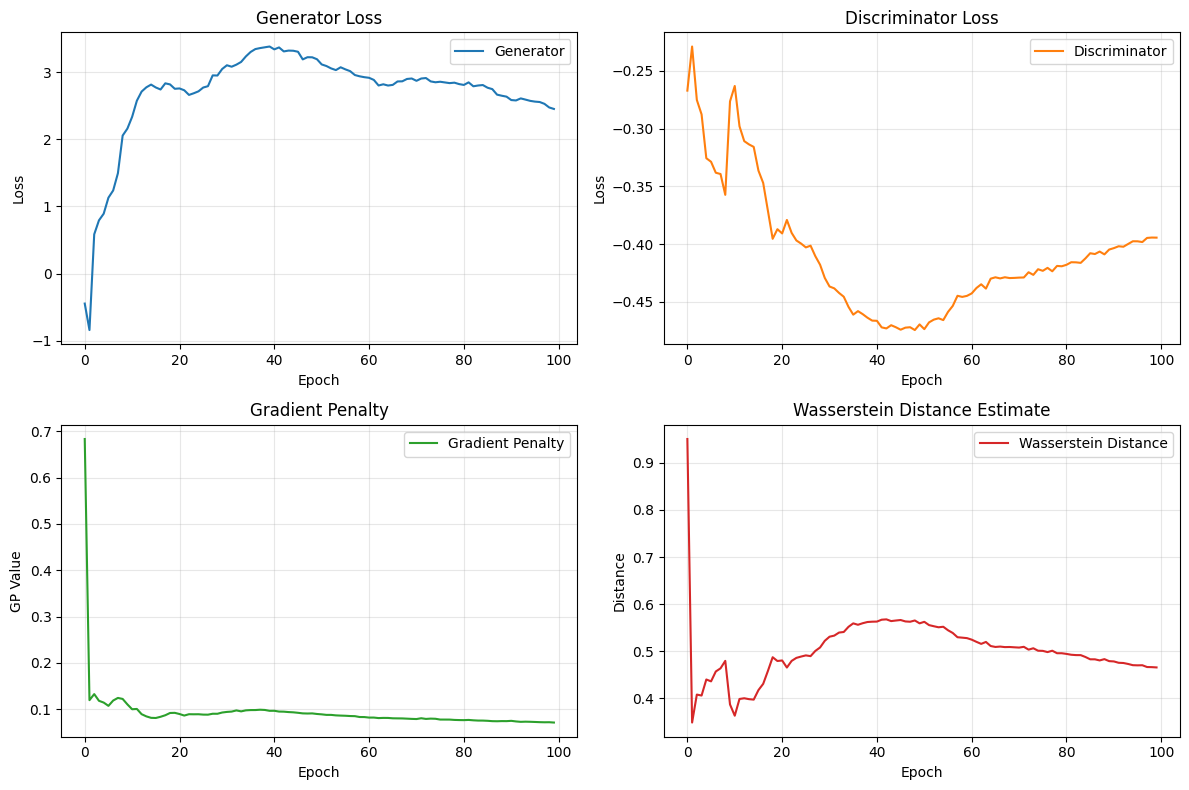

In [22]:
# ============================================================================
# 16. EVALUATION: VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("EVALUATION: VISUALIZATIONS")
print("="*80 + "\n")

# Plot training losses
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(result["history"]["g_loss"], label='Generator', color='tab:blue')
axes[0, 0].set_title("Generator Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(result["history"]["d_loss"], label='Discriminator', color='tab:orange')
axes[0, 1].set_title("Discriminator Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(result["history"]["gp"], label='Gradient Penalty', color='tab:green')
axes[1, 0].set_title("Gradient Penalty")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("GP Value")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(result["history"]["w_dist"], label='Wasserstein Distance', color='tab:red')
axes[1, 1].set_title("Wasserstein Distance Estimate")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Distance")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "training_metrics.png"), dpi=150, bbox_inches='tight')
plt.show()


Plotting distribution comparisons...


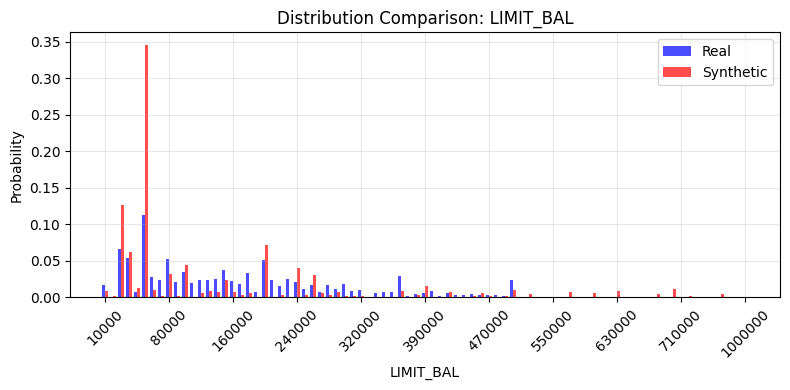

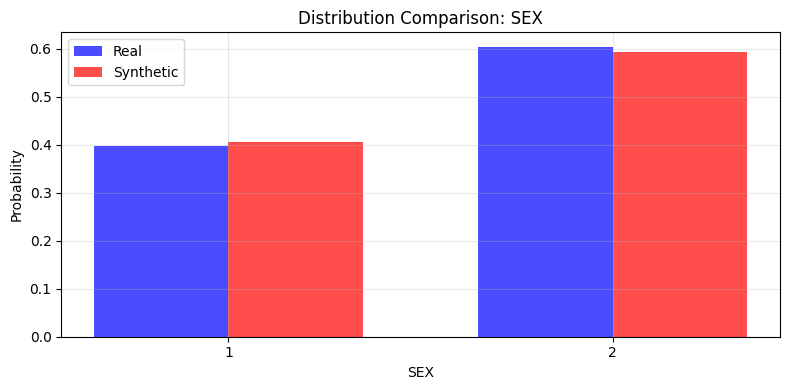

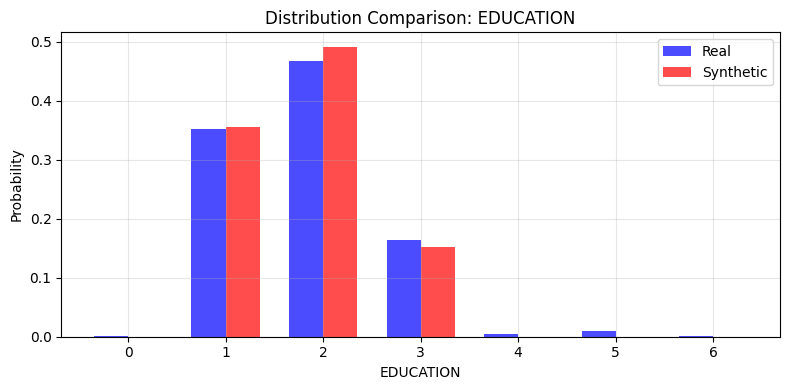

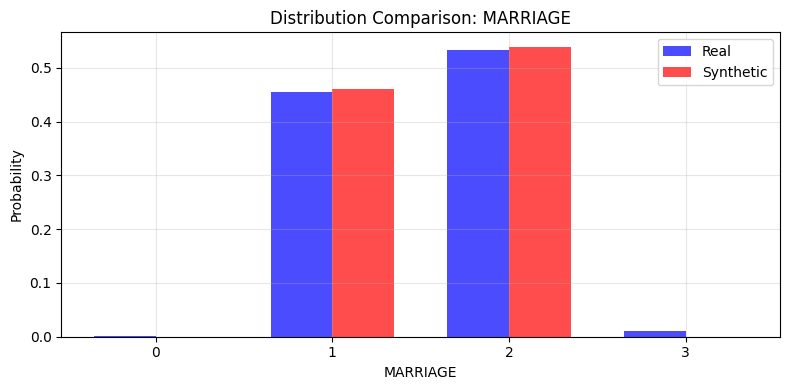

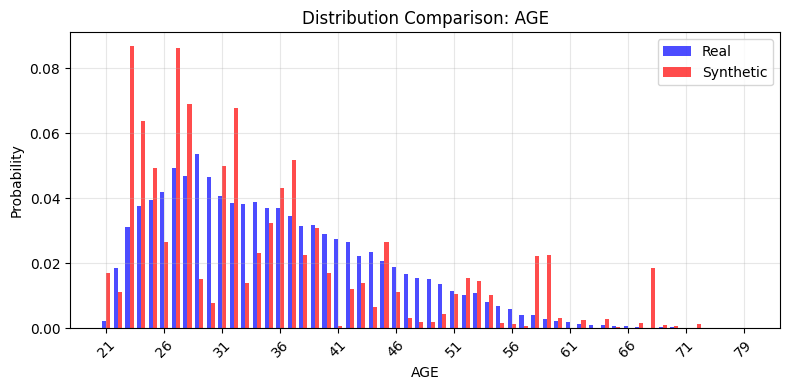

✅ Distribution plots completed


In [23]:
print("\nPlotting distribution comparisons...")
for col in df.columns[:5]:  # First 5 columns
    plt.figure(figsize=(8, 4))
    
    if col in num_cols:
        # Numeric column - use KDE
        sns.kdeplot(df[col], label='Real', fill=True, alpha=0.5, color='blue')
        sns.kdeplot(syn_df[col], label='Synthetic', fill=True, alpha=0.5, color='red')
    else:
        # Categorical column - use bar plot
        real_counts = df[col].value_counts(normalize=True)
        syn_counts = syn_df[col].value_counts(normalize=True)
        
        # ✨ FIX: Align categories
        all_categories = sorted(set(real_counts.index) | set(syn_counts.index))
        real_counts = real_counts.reindex(all_categories, fill_value=0)
        syn_counts = syn_counts.reindex(all_categories, fill_value=0)
        
        x = np.arange(len(all_categories))
        width = 0.35
        
        plt.bar(x - width/2, real_counts.values, width, label='Real', alpha=0.7, color='blue')
        plt.bar(x + width/2, syn_counts.values, width, label='Synthetic', alpha=0.7, color='red')
        
        # Smart tick labeling
        if len(all_categories) <= 20:
            plt.xticks(x, all_categories, rotation=45 if len(all_categories) > 10 else 0)
        else:
            step = max(1, len(all_categories) // 10)
            plt.xticks(x[::step], [all_categories[i] for i in range(0, len(all_categories), step)], rotation=45)
    
    plt.title(f'Distribution Comparison: {col}')
    plt.xlabel(col)
    plt.ylabel('Density' if col in num_cols else 'Probability')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f'dist_comparison_{col}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print("✅ Distribution plots completed")


EVALUATION: STATISTICAL TESTS

Kolmogorov-Smirnov Test (Numeric Columns):
------------------------------------------------------------
BILL_AMT1           : KS statistic = 0.0619, p-value = 0.000000
BILL_AMT2           : KS statistic = 0.0387, p-value = 0.000000
BILL_AMT3           : KS statistic = 0.0341, p-value = 0.000000
BILL_AMT4           : KS statistic = 0.0367, p-value = 0.000000
BILL_AMT5           : KS statistic = 0.0380, p-value = 0.000000
BILL_AMT6           : KS statistic = 0.0537, p-value = 0.000000
PAY_AMT1            : KS statistic = 0.0800, p-value = 0.000000
PAY_AMT2            : KS statistic = 0.1152, p-value = 0.000000
PAY_AMT3            : KS statistic = 0.0843, p-value = 0.000000
PAY_AMT4            : KS statistic = 0.0790, p-value = 0.000000
PAY_AMT5            : KS statistic = 0.0914, p-value = 0.000000
PAY_AMT6            : KS statistic = 0.0766, p-value = 0.000000

------------------------------------------------------------

Chi-Squared Test (Categorical Col

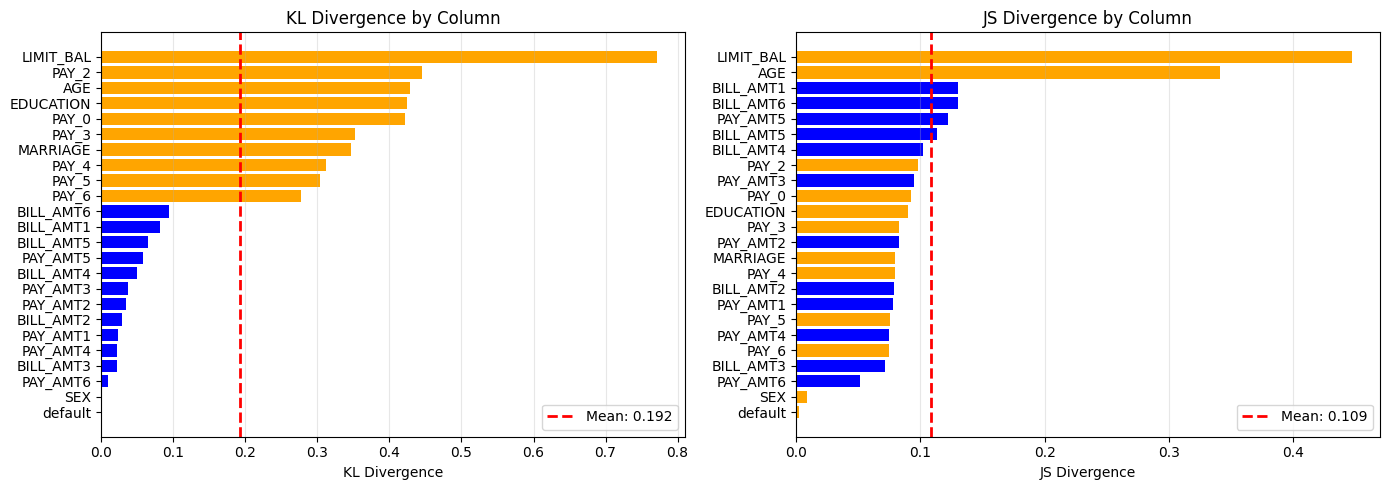

In [24]:
# ============================================================================
# 17. EVALUATION: STATISTICAL TESTS
# ============================================================================

print("\n" + "="*80)
print("EVALUATION: STATISTICAL TESTS")
print("="*80 + "\n")

# Kolmogorov-Smirnov test for numeric columns
print("Kolmogorov-Smirnov Test (Numeric Columns):")
print("-" * 60)
for col in num_cols:
    ks_stat, p_value = ks_2samp(df[col], syn_df[col])
    print(f"{col:20s}: KS statistic = {ks_stat:.4f}, p-value = {p_value:.6f}")

print("\n" + "-" * 60 + "\n")

# Chi-squared test for categorical columns
print("Chi-Squared Test (Categorical Columns):")
print("-" * 60)
for col in cat_cols:
    real_counts = df[col].value_counts()
    synth_counts = syn_df[col].value_counts()
    table = pd.concat([real_counts, synth_counts], axis=1).fillna(0)
    chi2, p, dof, expected = chi2_contingency(table.T)
    print(f"{col:20s}: χ² = {chi2:.4f}, p-value = {p:.6f}")

# ============================================================================
# 18. EVALUATION: KL AND JS DIVERGENCE
# ============================================================================

print("\n" + "="*80)
print("EVALUATION: KL AND JS DIVERGENCE")
print("="*80 + "\n")

# Compute divergences
divergence_results = compute_divergences_for_dataframes(df, syn_df, num_cols, cat_cols, bins=50)

print("KL and JS Divergence for all columns:")
print("-" * 80)
print(divergence_results.to_string(index=False))

# Save results
divergence_results.to_csv(os.path.join(out_dir, "divergence_results.csv"), index=False)

# Summary statistics
print("\n" + "-" * 80)
print("\nSummary Statistics:")
print(f"Average KL Divergence: {divergence_results['kl_divergence'].mean():.4f}")
print(f"Average JS Divergence: {divergence_results['js_divergence'].mean():.4f}")
print(f"\nMedian KL Divergence: {divergence_results['kl_divergence'].median():.4f}")
print(f"Median JS Divergence: {divergence_results['js_divergence'].median():.4f}")

# Visualize divergences
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KL Divergence
divergence_results_sorted = divergence_results.sort_values('kl_divergence')
axes[0].barh(divergence_results_sorted['column'], divergence_results_sorted['kl_divergence'], 
             color=['blue' if t == 'numeric' else 'orange' for t in divergence_results_sorted['type']])
axes[0].set_xlabel('KL Divergence')
axes[0].set_title('KL Divergence by Column')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].axvline(divergence_results['kl_divergence'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {divergence_results["kl_divergence"].mean():.3f}')
axes[0].legend()

# JS Divergence
divergence_results_sorted = divergence_results.sort_values('js_divergence')
axes[1].barh(divergence_results_sorted['column'], divergence_results_sorted['js_divergence'],
             color=['blue' if t == 'numeric' else 'orange' for t in divergence_results_sorted['type']])
axes[1].set_xlabel('JS Divergence')
axes[1].set_title('JS Divergence by Column')
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].axvline(divergence_results['js_divergence'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {divergence_results["js_divergence"].mean():.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "divergence_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ============================================================================
# 19. FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("TRAINING AND EVALUATION SUMMARY")
print("="*80)

print(f"\n1. Model Configuration:")
print(f"   - Architecture: CTAB-GAN with WGAN-GP")
print(f"   - Generator layers: {cfg.g_layers}")
print(f"   - Discriminator layers: {cfg.d_layers}")
print(f"   - Hidden dimensions: {cfg.g_hidden}")
print(f"   - Training epochs: {cfg.n_epochs}")
print(f"   - Batch size: {cfg.batch_size}")

print(f"\n2. Stabilization Techniques:")
print(f"   ✓ Wasserstein Loss with Gradient Penalty (λ={cfg.lambda_gp})")
print(f"   ✓ Spectral Normalization on Discriminator")
print(f"   ✓ Gradient Clipping (G={cfg.grad_clip_g}, D={cfg.grad_clip_d})")
print(f"   ✓ Instance Noise Annealing (σ₀={cfg.inst_noise_sigma0})")
print(f"   ✓ Layer Normalization")
print(f"   ✓ Orthogonal Weight Initialization")
print(f"   ✓ Dropout (p={cfg.dropout})")

if cfg.use_dp and 'epsilon' in result['history']:
    print(f"\n3. Differential Privacy:")
    print(f"   ✓ DP-SGD enabled")
    print(f"   - Noise multiplier: {cfg.dp_noise_multiplier}")
    print(f"   - Max gradient norm: {cfg.dp_max_grad_norm}")
    print(f"   - Privacy budget: ε = {result['history']['epsilon']:.2f} (δ = {cfg.dp_delta})")

print(f"\n4. Final Training Metrics:")
print(f"   - Generator Loss: {result['history']['g_loss'][-1]:.4f}")
print(f"   - Discriminator Loss: {result['history']['d_loss'][-1]:.4f}")
print(f"   - Gradient Penalty: {result['history']['gp'][-1]:.4f}")
print(f"   - Wasserstein Distance: {result['history']['w_dist'][-1]:.4f}")

print(f"\n5. Data Quality Metrics:")
print(f"   - Average KL Divergence: {divergence_results['kl_divergence'].mean():.4f}")
print(f"   - Average JS Divergence: {divergence_results['js_divergence'].mean():.4f}")
print(f"   - Columns with JS Divergence < 0.1: {(divergence_results['js_divergence'] < 0.1).sum()}/{len(divergence_results)}")

print(f"\n6. Output Files:")
print(f"   - Synthetic data: {out_csv}")
print(f"   - Divergence results: {os.path.join(out_dir, 'divergence_results.csv')}")
print(f"   - Training metrics plot: {os.path.join(out_dir, 'training_metrics.png')}")
print(f"   - Divergence plot: {os.path.join(out_dir, 'divergence_comparison.png')}")

print("\n" + "="*80)
print("COMPLETE!")
print("="*80 + "\n")


TRAINING AND EVALUATION SUMMARY

1. Model Configuration:
   - Architecture: CTAB-GAN with WGAN-GP
   - Generator layers: 3
   - Discriminator layers: 3
   - Hidden dimensions: 128
   - Training epochs: 100
   - Batch size: 64

2. Stabilization Techniques:
   ✓ Wasserstein Loss with Gradient Penalty (λ=10.0)
   ✓ Spectral Normalization on Discriminator
   ✓ Gradient Clipping (G=1.0, D=1.0)
   ✓ Instance Noise Annealing (σ₀=0.1)
   ✓ Layer Normalization
   ✓ Orthogonal Weight Initialization
   ✓ Dropout (p=0.1)

3. Differential Privacy:
   ✓ DP-SGD enabled
   - Noise multiplier: 0.5
   - Max gradient norm: 1.0
   - Privacy budget: ε = 1937.92 (δ = 1e-05)

4. Final Training Metrics:
   - Generator Loss: 2.4524
   - Discriminator Loss: -0.3944
   - Gradient Penalty: 0.0709
   - Wasserstein Distance: 0.4654

5. Data Quality Metrics:
   - Average KL Divergence: 0.1922
   - Average JS Divergence: 0.1085
   - Columns with JS Divergence < 0.1: 17/24

6. Output Files:
   - Synthetic data: Outpu

In [26]:
# Cell 1: imports & helper functions
import json
import numpy as np
import pandas as pd
from itertools import combinations
from typing import List, Tuple, Dict

from scipy.stats import ks_2samp, pearsonr
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from tqdm import tqdm

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# ---------- small helpers ----------
def total_variation_distance_counts(real_counts: np.ndarray, synth_counts: np.ndarray) -> float:
    p = real_counts.astype(float) / (real_counts.sum() + 1e-12)
    q = synth_counts.astype(float) / (synth_counts.sum() + 1e-12)
    return float(np.abs(p - q).sum())

# ---------- column fidelity ----------
def column_fidelity(real_df: pd.DataFrame, synth_df: pd.DataFrame,
                    categorical_cols: List[str], numeric_cols: List[str]) -> Tuple[Dict, float]:
    per_col = {}
    for col in numeric_cols:
        a = real_df[col].dropna().values
        b = synth_df[col].dropna().values
        if len(a) == 0 or len(b) == 0:
            ks_stat = 1.0
        else:
            ks_stat = ks_2samp(a, b).statistic
        omega = 1.0 - float(ks_stat)
        per_col[col] = {"type": "numeric", "ks": float(ks_stat), "omega_col": float(omega)}

    for col in categorical_cols:
        a = real_df[col].astype(str).fillna("__nan__").values
        b = synth_df[col].astype(str).fillna("__nan__").values
        real_counts = pd.Series(a).value_counts().sort_index()
        synth_counts = pd.Series(b).value_counts().reindex(real_counts.index, fill_value=0)
        tvd = total_variation_distance_counts(real_counts.values, synth_counts.values)
        omega = 1.0 - 0.5 * float(tvd)
        per_col[col] = {"type": "categorical", "tvd": float(tvd), "omega_col": float(omega)}

    Omega_col = float(np.mean([v["omega_col"] for v in per_col.values()]))
    return per_col, Omega_col

# ---------- row fidelity ----------
def compute_pairwise_row_fidelity(real_df: pd.DataFrame, synth_df: pd.DataFrame,
                                  categorical_cols: List[str], numeric_cols: List[str]) -> Tuple[Dict, float]:
    per_pair = {}
    scores = []

    # numeric-numeric pairs
    for a, b in combinations(numeric_cols, 2):
        ra = real_df[a].dropna().values
        rb = real_df[b].dropna().values
        sa = synth_df[a].dropna().values
        sb = synth_df[b].dropna().values
        try:
            rho_real = float(pearsonr(ra, rb)[0])
        except Exception:
            rho_real = 0.0
        try:
            rho_synth = float(pearsonr(sa, sb)[0])
        except Exception:
            rho_synth = 0.0
        delta = abs(rho_real - rho_synth)
        omega = 1.0 - 0.5 * delta
        per_pair[(a,b)] = {"type": "num-num", "rho_real": rho_real, "rho_synth": rho_synth, "omega_row": float(omega)}
        scores.append(omega)

    # categorical-categorical pairs (joint TVD)
    for a, b in combinations(categorical_cols, 2):
        ra = real_df[[a,b]].astype(str).fillna("__nan__")
        sa = synth_df[[a,b]].astype(str).fillna("__nan__")
        real_joint = ra.value_counts().sort_index()
        synth_joint = sa.value_counts().reindex(real_joint.index, fill_value=0)
        tvd = total_variation_distance_counts(real_joint.values, synth_joint.values)
        omega = 1.0 - 0.5 * float(tvd)
        per_pair[(a,b)] = {"type": "cat-cat", "tvd_joint": float(tvd), "omega_row": float(omega)}
        scores.append(omega)

    Omega_row = float(np.mean(scores)) if len(scores) > 0 else 0.0
    return per_pair, Omega_row

# ---------- DCR (privacy) ----------
def compute_DCR(real_df: pd.DataFrame, synth_df: pd.DataFrame,
                categorical_cols: List[str], numeric_cols: List[str]) -> float:
    scaler = StandardScaler()
    real_nums = real_df[numeric_cols].astype(float).fillna(0.0).values if len(numeric_cols)>0 else np.zeros((len(real_df),0))
    synth_nums = synth_df[numeric_cols].astype(float).fillna(0.0).values if len(numeric_cols)>0 else np.zeros((len(synth_df),0))
    if real_nums.shape[1] > 0:
        scaler.fit(real_nums)
        real_nums_s = scaler.transform(real_nums)
        synth_nums_s = scaler.transform(synth_nums)
    else:
        real_nums_s = np.zeros((len(real_df),0))
        synth_nums_s = np.zeros((len(synth_df),0))

    enc = OneHotEncoder(handle_unknown="ignore", sparse=False)
    if len(categorical_cols) > 0:
        real_cats = real_df[categorical_cols].astype(str).fillna("__nan__").values
        synth_cats = synth_df[categorical_cols].astype(str).fillna("__nan__").values
        enc.fit(real_cats)
        real_cats_ohe = enc.transform(real_cats)
        synth_cats_ohe = enc.transform(synth_cats)
    else:
        real_cats_ohe = np.zeros((len(real_df),0))
        synth_cats_ohe = np.zeros((len(synth_df),0))

    real_matrix = np.hstack([real_nums_s, real_cats_ohe])
    synth_matrix = np.hstack([synth_nums_s, synth_cats_ohe])

    nn = NearestNeighbors(n_neighbors=1, algorithm='auto', metric='euclidean')
    nn.fit(real_matrix)
    dists, _ = nn.kneighbors(synth_matrix, n_neighbors=1, return_distance=True)
    median_dcr = float(np.median(dists.ravel()))
    return median_dcr

# ---------- synthesis (exact match) ----------
def compute_synthesis(real_df: pd.DataFrame, synth_df: pd.DataFrame,
                      categorical_cols: List[str], numeric_cols: List[str]) -> float:
    if len(categorical_cols) > 0:
        real_cat_keys = real_df[categorical_cols].astype(str).fillna("__nan__").agg("||".join, axis=1)
        synth_cat_keys = synth_df[categorical_cols].astype(str).fillna("__nan__").agg("||".join, axis=1)
        groups = {}
        for idx, key in enumerate(real_cat_keys):
            groups.setdefault(key, []).append(idx)
    else:
        real_cat_keys = pd.Series(["_all_"] * len(real_df))
        synth_cat_keys = pd.Series(["_all_"] * len(synth_df))
        groups = {"_all_": list(range(len(real_df)))}

    real_nums = real_df[numeric_cols].astype(float).fillna(0.0).values
    synth_nums = synth_df[numeric_cols].astype(float).fillna(0.0).values

    matched = 0
    for i, key in enumerate(synth_cat_keys):
        candidate_idxs = groups.get(key, [])
        if len(candidate_idxs) == 0:
            continue
        s_vals = synth_nums[i] if len(numeric_cols)>0 else np.array([])
        r_vals = real_nums[candidate_idxs] if len(numeric_cols)>0 else np.array([[]])
        if r_vals.size == 0 and s_vals.size == 0:
            matched += 1
            continue
        abs_diffs = np.abs(r_vals - s_vals[None, :])
        rel_bounds = 0.01 * (np.abs(r_vals) + 1e-12)
        within = (abs_diffs <= rel_bounds) | (abs_diffs <= 1e-6)
        row_all = within.all(axis=1)
        if row_all.any():
            matched += 1
    return float(matched / len(synth_df))

# ---------- utility (train on synth, test on real) ----------
def compute_utility_accuracy(real_test_df: pd.DataFrame, synth_train_df: pd.DataFrame,
                             label_col: str) -> Tuple[Dict[str,float], float]:

    models = {
        # 🌲 Random Forest — deeper trees, balanced subsampling for stability
        "RandomForest": RandomForestClassifier(
            n_estimators=300,           # more trees → better generalization
            max_depth=15,               # limits overfitting
            min_samples_split=4,        # ensures splits are meaningful
            min_samples_leaf=2,
            max_features="sqrt",        # common best practice for classification
            bootstrap=True,
            n_jobs=-1,
            random_state=42
        ),
    
        # 🌳 Decision Tree — slightly regularized to avoid overfitting
        "DecisionTree": DecisionTreeClassifier(
            criterion="gini",
            max_depth=10,               # limits overfitting
            min_samples_split=5,
            min_samples_leaf=3,
            random_state=42
        ),
    
        # 📈 Logistic Regression — stronger regularization and robust solver
        "LogisticRegression": LogisticRegression(
            max_iter=1000,
            solver="lbfgs"
        ),
    
        # 🚀 AdaBoost — more estimators + tuned learning rate
        "AdaBoost": AdaBoostClassifier(
            n_estimators=200,
            learning_rate=0.5,          # smaller LR helps smoother convergence
            random_state=42
        )
            #,
    
        # # 🤓 Naive Bayes — standard (no major tuning options)
        # "NaiveBayes": GaussianNB(var_smoothing=1e-9)  # small var smoothing helps numerical stability
    }

    synth_train_df = synth_train_df[real_test_df.columns]
    X_train=synth_train_df.drop(columns=[label_col])
    X_test=real_test_df.drop(columns=[label_col])
    y_train=synth_train_df[label_col]
    y_test= real_test_df[label_col]

    accuracies = {}
    accs=[]
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        curr_acc=accuracy_score(y_test, preds)
        accuracies[name] = curr_acc
        accs.append(curr_acc)
    mean_acc = float(np.mean(accs))
    return accuracies, mean_acc

In [27]:
numeric_cols=['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
categorical_cols=['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'default']

In [28]:
label_col = "default"  
real_df = pd.read_csv("/kaggle/input/taiwan-credit-card-dataset/data.csv")
#real_df=real_df.drop(columns=["ID"])
#real_df=test_df
synth_df = pd.read_csv("/kaggle/working/Outputs/synth_dp.csv")
cat_cols = categorical_cols
num_cols = numeric_cols

print("Computing column fidelity...")
per_col, Omega_col = column_fidelity(real_df, synth_df, cat_cols, num_cols)

print("Computing row fidelity (pairwise)...")
per_pair, Omega_row = compute_pairwise_row_fidelity(real_df, synth_df, cat_cols, num_cols)

print("Computing privacy (DCR median)...")
median_dcr = compute_DCR(real_df, synth_df, cat_cols, num_cols)

print("Computing synthesis fraction (exact/1% matches)...")
synth_frac = compute_synthesis(real_df, synth_df, cat_cols, num_cols)

print("Computing utility (train on synth, test on real)...")
utility_per_clf, utility_mean = compute_utility_accuracy(real_df, synth_df,label_col)

# Summarize
summary = {
    "Omega_col": Omega_col,
    "Omega_row": Omega_row,
    "privacy_median_DCR": median_dcr,
    "synthesis_fraction": synth_frac,
    "utility_mean_accuracy": utility_mean,
    "utility_per_classifier": utility_per_clf
}

print("\n=== Evaluation Summary ===")
print(f"Omega_col (column fidelity avg): {Omega_col:.4f}")
print(f"Omega_row (row fidelity avg):    {Omega_row:.4f}")
print(f"Privacy (median DCR):            {median_dcr:.6f}")
print(f"Utility (mean accuracy):         {utility_mean:.4f}")
print(f"Synthesis (match frac):          {synth_frac:.6f}")

Computing column fidelity...
Computing row fidelity (pairwise)...
Computing privacy (DCR median)...
Computing synthesis fraction (exact/1% matches)...
Computing utility (train on synth, test on real)...

=== Evaluation Summary ===
Omega_col (column fidelity avg): 0.9281
Omega_row (row fidelity avg):    0.8910
Privacy (median DCR):            1.486242
Utility (mean accuracy):         0.7907
Synthesis (match frac):          0.000033


In [29]:
# Cell 3: save results to disk for record-keeping
out_json = "finDiff_eval_results.json"
out_csv = "finDiff_eval_per_column.csv"

# write JSON
with open(out_json, "w") as f:
    json.dump({
        "summary": summary,
        "per_column": per_col,
        "per_pair": {str(k):v for k,v in per_pair.items()}
    }, f, indent=2)
print("Saved evaluation JSON:", out_json)

# optional: save per-column table
per_col_df = pd.DataFrame.from_dict(per_col, orient="index")
per_col_df.to_csv(out_csv)
print("Saved per-column CSV:", out_csv)

Saved evaluation JSON: finDiff_eval_results.json
Saved per-column CSV: finDiff_eval_per_column.csv
